Task 1 — Linear Regression: House Price Prediction

Predicting house price from bedrooms, bathrooms, size, and location.

In [27]:
#IMPORTING REQUIRED LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
#PART1
#Loading the csv data into a pandas dataframe
df = pd.read_csv(r"C:\Users\USER\Desktop\data.csv")

In [3]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [4]:
df.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.value_counts()

date                 price      bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  yr_renovated  street                  city           statezip  country
2014-05-02 00:00:00  235000.0   2.0       1.00       1210         9400      1.0     0           0     2          1210        0              1949      0             7542 21st Ave SW        Seattle        WA 98106  USA        1
2014-06-19 00:00:00  519000.0   3.0       2.75       2020         10744     1.0     0           0     5          1270        750            1954      0             18107-18199 6th Ave SW  Normandy Park  WA 98166  USA        1
                     576000.0   3.0       2.50       1940         9000      1.0     0           0     4          970         970            1948      0             8817 28th Ave NW        Seattle        WA 98117  USA        1
                     558000.0   4.0       2.25       2060         10358     1.0     0           0    

In [7]:
# No nulls — but check for bad data: rows where price is 0 (not a real sale)
print('Zero_price rows:', (df['price'] == 0).sum())
df = df[df['price'] > 0].reset_index(drop=True)
print('Shape after removing them:', df.shape)

Zero_price rows: 49
Shape after removing them: (4551, 18)


In [8]:
# Quick summary stats
df[['price', 'bedrooms', 'bathrooms', 'sqft_living', 'floors', 'condition']].describe()

,price,bedrooms,bathrooms,sqft_living,floors,condition
count,4.551000e+03,4551.000000,4551.000000,4551.000000,4551.000000,4551.000000
mean,5.579059e+05,3.394639,2.155021,2132.372226,1.512195,3.449352
std,5.639299e+05,0.904595,0.776351,955.949708,0.538531,0.675160
min,7.800000e+03,0.000000,0.000000,370.000000,1.000000,1.000000
25%,3.262643e+05,3.000000,1.750000,1460.000000,1.000000,3.000000
50%,4.650000e+05,3.000000,2.250000,1970.000000,1.500000,3.000000
75%,6.575000e+05,4.000000,2.500000,2610.000000,2.000000,4.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,3.500000,5.000000


In [10]:
df['country'].unique()

array(['USA'], dtype=object)

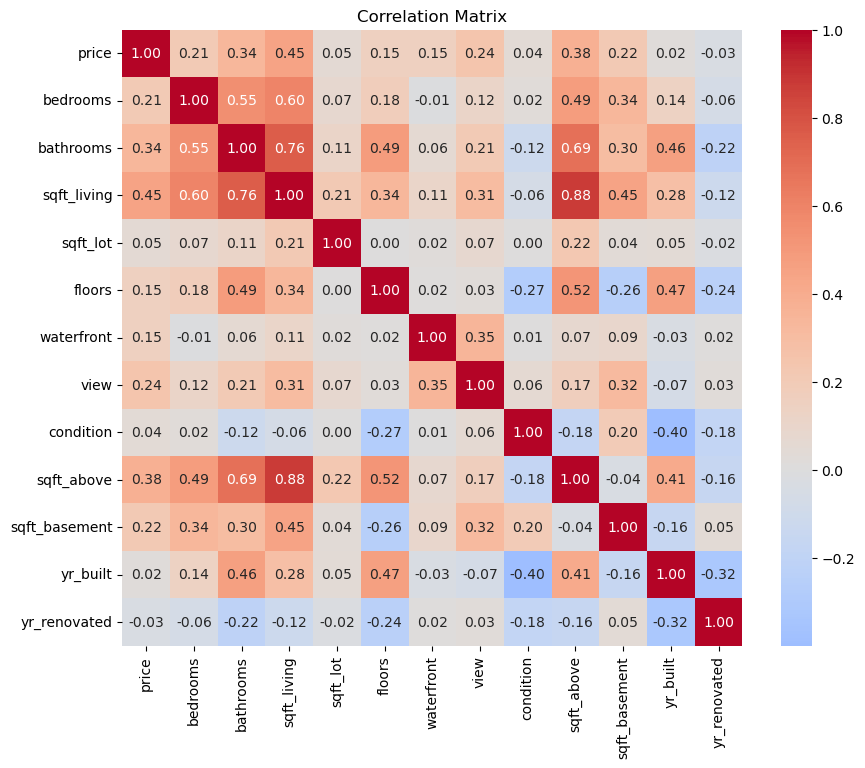

sqft_living      0.445494
sqft_above       0.380661
bathrooms        0.341126
view             0.242587
sqft_basement    0.217782
bedrooms         0.210228
floors           0.152758
waterfront       0.150083
sqft_lot         0.051347
condition        0.038892
yr_built         0.021757
yr_renovated    -0.029034
Name: price, dtype: float64

In [12]:
numeric_cols = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
                 'floors', 'waterfront', 'view', 'condition', 'sqft_above',
                 'sqft_basement', 'yr_built', 'yr_renovated']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()
# Which columns correlate most strongly with price?
corr_matrix['price'].drop('price').sort_values(ascending=False)

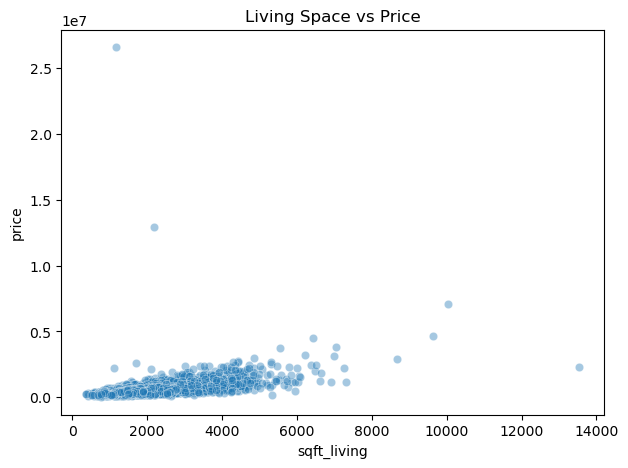

In [13]:
# Visualize relationship between living space and price
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='sqft_living', y='price', alpha=0.4)
plt.title('Living Space vs Price')
plt.show()

In [14]:
top_cities = df['city'].value_counts().nlargest(10).index
df['city_grouped'] = df['city'].where(df['city'].isin(top_cities), 'Other')
df['city_grouped'].value_counts()

city_grouped
Seattle        1561
Other          1135
Renton          291
Bellevue        281
Redmond         235
Kirkland        187
Issaquah        186
Kent            184
Auburn          175
Sammamish       171
Federal Way     145
Name: count, dtype: int64

In [15]:
features = ['bedrooms', 'bathrooms', 'sqft_living', 'floors', 'condition',
            'waterfront', 'view', 'yr_built', 'city_grouped']

df_model = df[features + ['price']].copy()
df_encoded = pd.get_dummies(df_model, columns=['city_grouped'], drop_first=True)
df_encoded.head()

,bedrooms,bathrooms,sqft_living,floors,condition,waterfront,view,yr_built,price,city_grouped_Bellevue,city_grouped_Federal Way,city_grouped_Issaquah,city_grouped_Kent,city_grouped_Kirkland,city_grouped_Other,city_grouped_Redmond,city_grouped_Renton,city_grouped_Sammamish,city_grouped_Seattle
0,3.0,1.50,1340,1.5,3,0,0,1955,313000.0,False,False,False,False,False,True,False,False,False,False
1,5.0,2.50,3650,2.0,5,0,4,1921,2384000.0,False,False,False,False,False,False,False,False,False,True
2,3.0,2.00,1930,1.0,4,0,0,1966,342000.0,False,False,False,True,False,False,False,False,False,False
3,3.0,2.25,2000,1.0,4,0,0,1963,420000.0,True,False,False,False,False,False,False,False,False,False
4,4.0,2.50,1940,1.0,4,0,0,1976,550000.0,False,False,False,False,False,False,True,False,False,False


In [16]:
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

print('Features:', list(X.columns))

Features: ['bedrooms', 'bathrooms', 'sqft_living', 'floors', 'condition', 'waterfront', 'view', 'yr_built', 'city_grouped_Bellevue', 'city_grouped_Federal Way', 'city_grouped_Issaquah', 'city_grouped_Kent', 'city_grouped_Kirkland', 'city_grouped_Other', 'city_grouped_Redmond', 'city_grouped_Renton', 'city_grouped_Sammamish', 'city_grouped_Seattle']


In [17]:
##Splitting data into training and test set 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training set size:', X_train.shape)
print('Testing set size:', X_test.shape)

Training set size: (3640, 18)
Testing set size: (911, 18)


In [25]:
#Train the linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred.round(0)})
results.head(10)

,Actual,Predicted
471,1225000.0,1460457.0
2518,496752.0,665373.0
23,612500.0,587728.0
3922,265000.0,142032.0
135,615000.0,592039.0
1789,432000.0,465937.0
3335,305000.0,368373.0
2374,405000.0,261107.0
2320,349000.0,453970.0
3260,839000.0,727180.0


In [28]:
##Evaluate the Model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'RMSE: ${rmse:,.2f}')
print(f'MAE:  ${mae:,.2f}')
print(f'R²:   {r2:.3f}')

RMSE: $227,589.82
MAE:  $140,623.76
R²:   0.652


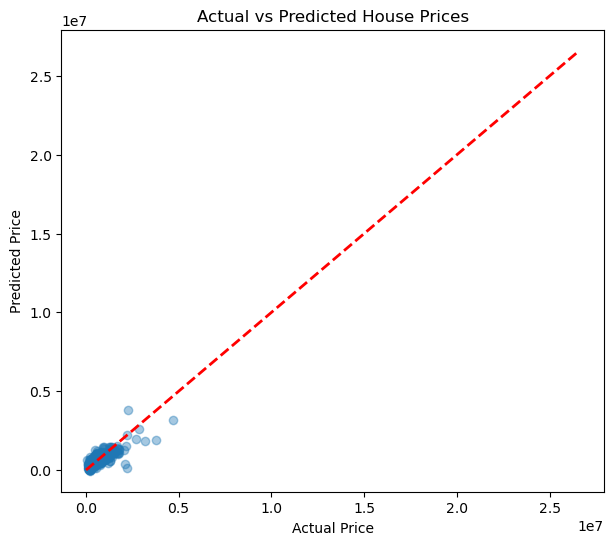

In [29]:
# Visualize actual vs predicted
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.show()